In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import csv
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import torch
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import random
import re
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import truncnorm

import src.architectures.networkArchitectures as netArch # Assuming this is where your registry code lives
from src.robustness.general_classes import ModelBridge
from src.robustness.milp_functions import *
from src.architectures.networkArchitectures import networkRegistry
from src.robustness.exactRobustness import exactRobustness
from src.robustness.fastLin import fastLin
from src.testing.networkTesting import testNetwork
from src.training.networkTraining import trainNetwork, saveNetwork
from src.utils.extractParams import extractParams
from src.utils.loadNetwork import loadNetwork

In [ ]:
# -------- WARNING - If the networks are retrained, all the current results won't match ------------
"""
# Train networks in registry
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

numEpochs = 2

for name, entry in networkRegistry.items():
    print(f"\nTraining {name}...")

    model = entry.NetworkClass()

    durations = trainNetwork(model, numEpochs, device)
    saveNetwork(model, name)

    print(f"Finished {name} | epoch times: {durations}")
"""

In [3]:
# Loads the data
transform = transforms.ToTensor()
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
all_images = test_data.data.numpy()   # (10000, 28, 28)
all_labels = test_data.targets.numpy() # (10000,)

# 🧪 Experiment 1 — Robustness Analysis

**Goal:**  
Analyze the robustness of MNIST samples and how it relates to network architecture.

---

### Setup

- Classes considered: **0, 1, 3**
- Norm used: **L1**

This setup will remain consistent throughout the experiments

---

### Procedure

1. **Fast approximation (FastLin)**
   - Test `numberOfFastLinImages` samples per class
   - Applied to each network

2. **Exact computation**
   - Test `numberOfExactImages` samples per class
   - Applied to each network

3. **Data analysis** (not yet done)
   - Plot histogram of the robustness results per class (exact and fastlin side by side)
   - Fit least-square lines (or polynomials or something) to robustness vs number of neurons and robustness vs number of layers
   - Covariance between number of layers vs robustness and number of neurons
   - Fit linear approximator
---

### ⚠️ Note

FastLin is much faster than exact methods.  
👉 It is recommended to use fewer samples for the exact computations.

In [17]:
numberOfFastLinImages = 70 # Per class
classes_to_test = (0, 1, 3)
pNorm = 1

## FastLin Testing of MNIST

In [18]:
# 11 min execution with numberOfFastLinImages = 33


resultsDirectory = Path("results")
fileName = "Exp1FastLinRobustnessResults.csv"
filePath = resultsDirectory / fileName

# Load already completed results
if filePath.exists():
    df = pd.read_csv(filePath)
    computedResults = set(zip(df["name"], df["imageIndex"], df["pNorm"], df["exactRobustness"]))
else:
    computedResults = set()

# Open CSV for appending
fileExists = filePath.exists()

with filePath.open(mode = "a", newline = "") as file:
    writer = csv.writer(file)

    # Create header if file does not already exist
    if not fileExists:
        writer.writerow(["network_name", "imageIndex", "label", "predictedClass", "pNorm", "exactRobustness", "epsilon"])

    for networkName in networkRegistry:
        print(networkName)
        print(f"Computing Fast-Lin for network: {networkName} (pNorm = {pNorm})")
        network = loadNetwork(networkName)

        parameters = extractParams(network = network, inputShape = (1, 28, 28))
        weights = [W for W, _ in parameters]
        biases = [b for _, b in parameters]

        for cls in classes_to_test:
            indices = np.where(all_labels == cls)[0]            
            selected_indices = random.sample(list(indices), min(numberOfFastLinImages, len(indices)))

            for imageIndex in tqdm(selected_indices):
                # Skip image if already computed for the network using Fast-Lin
                if (networkName, imageIndex, pNorm, False) in computedResults:
                    continue

                # Compute results
                image, label = test_data[imageIndex]
                x0 = image.view(-1).numpy()

                output = network(image)
                _, predictedClass = torch.max(output, 1)
                predictedClass = predictedClass.item()
                targetClasses = [targetClass for targetClass in range(0, 10) if targetClass != predictedClass]
                
                certifiedEpsilon, _, _ = fastLin(weights = weights, biases = biases, x0 = x0, pNorm = pNorm, epsilon0 = 10, originalClass = predictedClass, targetClasses = targetClasses, tolerance = 0.005)

                # Save computed results
                writer.writerow([networkName, imageIndex, label, predictedClass, pNorm, False, certifiedEpsilon])
                file.flush()

Dense1x60
Computing Fast-Lin for network: Dense1x60 (pNorm = 1)


100%|██████████| 70/70 [00:05<00:00, 12.50it/s]


Dense2x30
Computing Fast-Lin for network: Dense2x30 (pNorm = 1)


100%|██████████| 70/70 [00:08<00:00,  8.50it/s]


Dense3x20
Computing Fast-Lin for network: Dense3x20 (pNorm = 1)


...

100%|██████████| 70/70 [00:12<00:00,  5.79it/s]


Dense2x32
Computing Fast-Lin for network: Dense2x32 (pNorm = 1)


100%|██████████| 70/70 [00:08<00:00,  8.53it/s]


Dense3x48
Computing Fast-Lin for network: Dense3x48 (pNorm = 1)


100%|██████████| 70/70 [00:14<00:00,  4.90it/s]


## Exact testing of MNIST

In [ ]:
numberOfExactImages = 3 # Per class per network

# Where to place results
resultsDir = Path("results")
resultsDir.mkdir(exist_ok=True)
filePath = resultsDir / "Exp1ExactRobustnessResults.csv"
fastLinPath = resultsDir / "Exp1FastLinRobustnessResults.csv"

# Load already computed results (Network, ImageIndex) to avoid duplicates
computed_pairs = set()
if filePath.exists() and filePath.stat().st_size > 0:
    df_old = pd.read_csv(filePath)
    computed_pairs = set(zip(df_old["name"], df_old["imageIndex"]))

# We are going to test a subset of the samples tested through fastLin, so we load that data
fastlin_indices = {}
if fastLinPath.exists():
    df_fl = pd.read_csv(fastLinPath)
    for net in df_fl["name"].unique():
        fastlin_indices[net] = df_fl[df_fl["name"] == net]["imageIndex"].tolist()


with filePath.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if not filePath.exists() or filePath.stat().st_size == 0:
        writer.writerow(["name", "imageIndex", "label", "predictedClass", "pNorm", "exactRobustness", "epsilon"])
    for networkName in netArch.networkRegistry.keys():
        print(f"\n--- Initializing Network Template: {networkName} ---")
        
        # Load the network 
        NetworkClass = netArch.networkRegistry[networkName].NetworkClass
        model_pt = NetworkClass()
        model_pt.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        model_pt.eval()
        bridge = ModelBridge(model_pt)
        bridge.load_layers_from_pytorch_model(L0=0, U0=1, input_shape=(784,))
        # The first layer will be bound tightened exactly. Only worth it if alot of samples are tested.
        bridge.layers[0].do_exact_bound_tightening() 
        bridge.setup_gurobi_logic()
        
        # We will only use the gurobi model in this state to copy it later, the template variable is just for clarity 
        template_model = bridge.gurobi_model 

        for cls in classes_to_test:
            # Selects the correct samples to test
            pool = [idx for idx in fastlin_indices.get(networkName, []) if all_labels[idx] == cls]
            if not pool: pool = np.where(all_labels == cls)[0].tolist()
            pool = [idx for idx in pool if (networkName, idx) not in computed_pairs]
            if not pool: continue
            selected_indices = random.sample(pool, min(numberOfExactImages, len(pool)))

            for idx in selected_indices:
                try:
                    img_flat_np = all_images[idx].flatten().astype(np.float32) / 255.0
                    label = int(all_labels[idx])

                    # Computes the networks classification of the unperturbed sample
                    img_torch = torch.from_numpy(img_flat_np).unsqueeze(0)
                    with torch.no_grad():
                        output = model_pt(img_torch)
                        predicted_class = int(torch.argmax(output, dim=1).item())

                    # Each robustness test introduces new variables to the model.
                    # Therefore we make a copy of the template so as to not optimize redundant variables
                    sample_model = template_model.copy()
                                    
                    # Add sample-specific robustness constraints and variables and objective to the copy
                    robustness_setup(img_flat_np, label, bridge, g_model=sample_model, max_d=1.0)

                    # The main test
                    eps, _, _ = standard_robustness_test(bridge, g_model=sample_model)
                    if eps is None: continue # If timeout
                    
                    writer.writerow([networkName, int(idx), label, predicted_class, pNorm, True, float(eps)])
                    file.flush()
                    print(f"  [Success] {networkName} Idx {idx}: Eps {eps:.4f}")
                    # Explicitly dispose of the copy to free up memory
                    sample_model.dispose() 

                except Exception as e:
                    print(f"  [Error] {networkName} Idx {idx}: {e}")


--- Initializing Network Template: Dense1x60 ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90


Setting up neuron 60: 100%|██████████| 60/60 [00:10<00:00,  5.76it/s]


Optimal solution found!
  [Success] Dense1x60 Idx 5519: Eps 3.2229
Optimal solution found!
  [Success] Dense1x60 Idx 459: Eps 5.0701
Optimal solution found!
  [Success] Dense1x60 Idx 4186: Eps 8.0713
Optimal solution found!
  [Success] Dense1x60 Idx 2974: Eps 4.6666
Optimal solution found!
  [Success] Dense1x60 Idx 7319: Eps 5.5724
Optimal solution found!
  [Success] Dense1x60 Idx 4304: Eps 5.8105
Optimal solution found!
  [Success] Dense1x60 Idx 8393: Eps 5.1350
Optimal solution found!
  [Success] Dense1x60 Idx 7140: Eps 4.7433
Optimal solution found!
  [Success] Dense1x60 Idx 9790: Eps 5.0288

--- Initializing Network Template: Dense2x30 ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90


Setting up neuron 30: 100%|██████████| 30/30 [00:03<00:00,  7.68it/s]


Optimal solution found!
  [Success] Dense2x30 Idx 3883: Eps 13.4192
Optimal solution found!
  [Success] Dense2x30 Idx 6925: Eps 7.8544
Optimal solution found!
  [Success] Dense2x30 Idx 2178: Eps 9.5274
Optimal solution found!
  [Success] Dense2x30 Idx 7811: Eps 1.5180
Optimal solution found!
  [Success] Dense2x30 Idx 9622: Eps 4.6264
Optimal solution found!
  [Success] Dense2x30 Idx 1329: Eps 5.7111
Optimal solution found!
  [Success] Dense2x30 Idx 5418: Eps 10.0269
Optimal solution found!
  [Success] Dense2x30 Idx 4928: Eps 3.2109
Optimal solution found!
  [Success] Dense2x30 Idx 8430: Eps 1.7309

--- Initializing Network Template: Dense3x20 ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90


...

No solution found
No solution found
Optimal solution found!
  [Success] Dense3x36 Idx 1176: Eps 3.7802
No solution found
No solution found
No solution found
No solution found
No solution found
No solution found

--- Initializing Network Template: Dense2x32 ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90


Setting up neuron 32: 100%|██████████| 32/32 [00:04<00:00,  7.25it/s]


Optimal solution found!
  [Success] Dense2x32 Idx 2932: Eps 3.4592
No solution found
No solution found
No solution found
Optimal solution found!
  [Success] Dense2x32 Idx 9657: Eps 4.4758
Optimal solution found!
  [Success] Dense2x32 Idx 5746: Eps 1.4198
Optimal solution found!
  [Success] Dense2x32 Idx 747: Eps 7.9984
Optimal solution found!
  [Success] Dense2x32 Idx 648: Eps 7.9962
Optimal solution found!
  [Success] Dense2x32 Idx 4106: Eps 4.0396

--- Initializing Network Template: Dense3x48 ---
Set parameter Username
Set parameter LicenseID to value 2785972
Academic license - for non-commercial use only - expires 2027-03-02
Set parameter TimeLimit to value 90


Setting up neuron 48: 100%|██████████| 48/48 [00:06<00:00,  7.15it/s]


No solution found
No solution found
No solution found
No solution found
No solution found
No solution found
No solution found
No solution found
No solution found


## Data Analysis

In [19]:
SET_MISCLASSIFIED_TO_ZERO = False 

# Load results
df_exact = pd.read_csv("results/Exp1ExactRobustnessResults.csv")
df_fast = pd.read_csv("results/Exp1FastLinRobustnessResults.csv")

# 1. Ignore the 3x200 network results, for now.
df_exact = df_exact[df_exact['name'] != 'Dense3x200']
df_fast = df_fast[df_fast['name'] != 'Dense3x200']

# 2. Handle Misclassifications
if SET_MISCLASSIFIED_TO_ZERO:
    # Set epsilon to 0 where prediction != label
    df_exact.loc[df_exact['predictedClass'] != df_exact['label'], 'epsilon'] = 0.0
    df_fast.loc[df_fast['predictedClass'] != df_fast['label'], 'epsilon'] = 0.0
    print(f"Mode: Misclassifications set to 0.0")
else:
    # Filter out misclassifications
    df_exact = df_exact[df_exact['predictedClass'] == df_exact['label']]
    df_fast = df_fast[df_fast['predictedClass'] == df_fast['label']]
    print(f"Mode: Misclassifications removed from dataset")

# 3. Update the classes list for subsequent plots
classes = sorted(df_exact['label'].unique())

print(f"Filters applied. Samples - Exact: {len(df_exact)}, Fast-Lin: {len(df_fast)}")

Mode: Misclassifications removed from dataset
Filters applied. Samples - Exact: 824, Fast-Lin: 10900


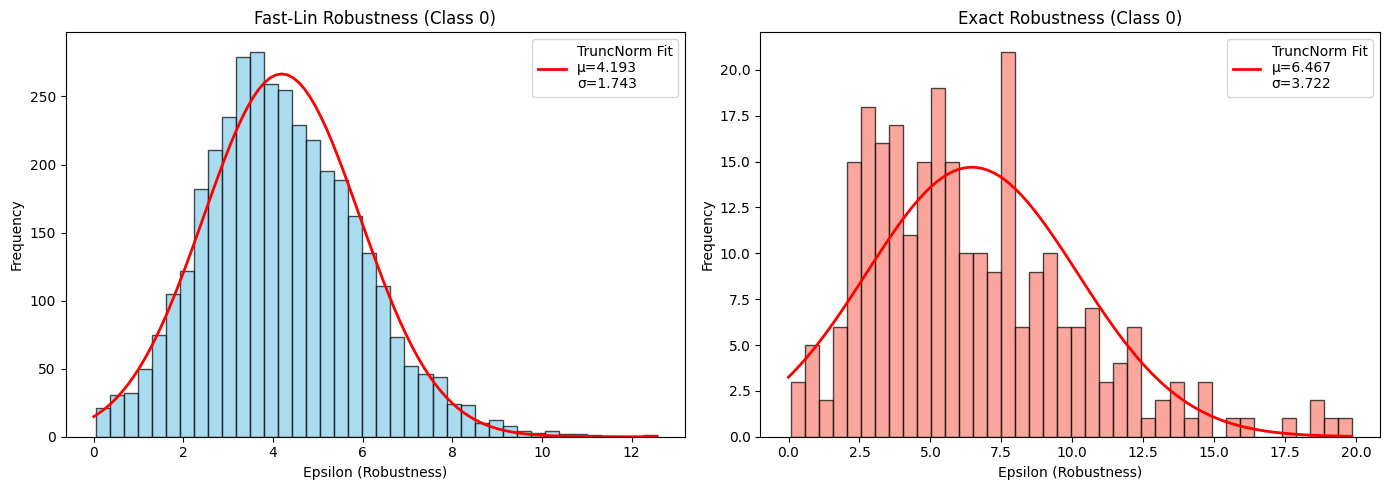

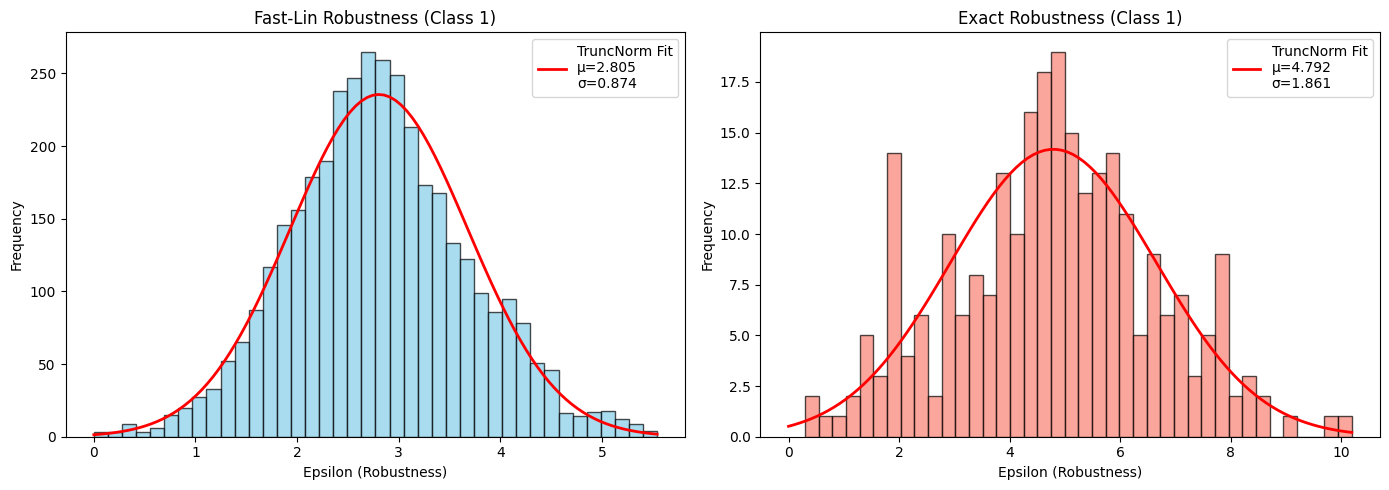

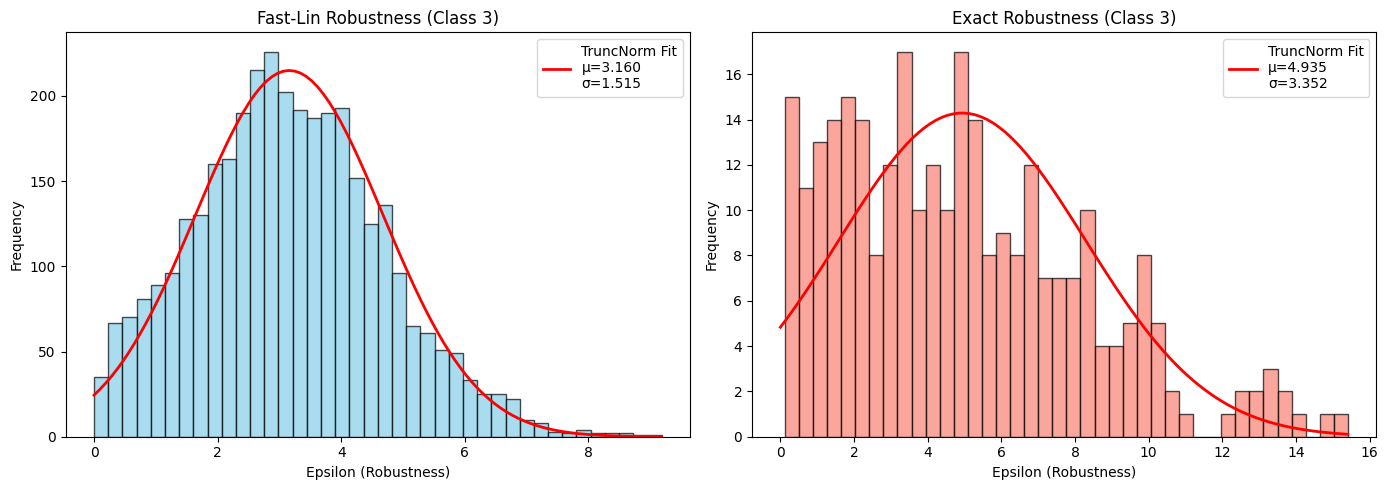

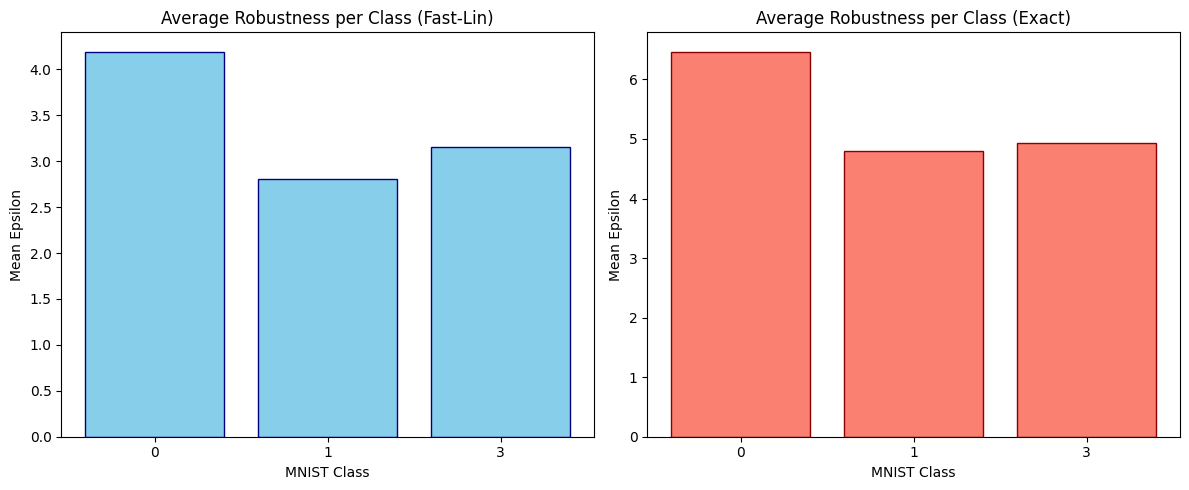

--- Robustness Variances ---
Class 0 | Fast-Lin Var: 3.037221 | Exact Var: 13.856365
Class 1 | Fast-Lin Var: 0.764552 | Exact Var: 3.461842
Class 3 | Fast-Lin Var: 2.295752 | Exact Var: 11.234070


In [21]:

n_bins = 40

# --- Histograms with Truncated Normal Overlay ---
for cls in classes:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    datasets = [
        (df_fast[df_fast['label'] == cls]['epsilon'], ax1, "Fast-Lin", "skyblue"),
        (df_exact[df_exact['label'] == cls]['epsilon'], ax2, "Exact", "salmon")
    ]
    
    for data, ax, title, color in datasets:
        # 1. Plot the histogram
        counts, bins, _ = ax.hist(data, bins=n_bins, color=color, edgecolor='black', alpha=0.7)
        
        if len(data) > 1: # Fitting requires at least a few points
            # 2. Fit truncated normal parameters
            # We fix the lower bound at 0 and upper bound at infinity
            # fit() returns (shape_a, shape_b, loc, scale)
            # But standard norm.fit parameters are loc and scale. 
            # For a more stable fit on truncated data, we use the sample mean/std as starting guesses
            my_loc, my_scale = data.mean(), data.std()
            
            # truncnorm.fit is tricky; often better to fit parameters using stats.norm 
            # and then express bounds relative to those.
            a_bound = (0 - my_loc) / my_scale
            b_bound = np.inf
            
            # 3. Generate X values for the curve
            x_range = np.linspace(0, data.max(), 100)
            pdf_values = truncnorm.pdf(x_range, a_bound, b_bound, loc=my_loc, scale=my_scale)
            
            # 4. Scale PDF to match histogram counts
            # Scale factor = Total Samples * Bin Width
            bin_width = bins[1] - bins[0]
            scaled_pdf = pdf_values * len(data) * bin_width
            
            ax.plot(x_range, scaled_pdf, 'r-', lw=2, 
                    label=f'TruncNorm Fit\nμ={my_loc:.3f}\nσ={my_scale:.3f}')
        
        ax.set_title(f"{title} Robustness (Class {cls})")
        ax.set_xlabel("Epsilon (Robustness)")
        ax.set_ylabel("Frequency")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

# --- Average Robustness Bar Diagrams ---
# (Rest of your bar chart and variance printing code remains the same)
avg_fast = df_fast.groupby('label')['epsilon'].mean()
var_fast = df_fast.groupby('label')['epsilon'].var()
avg_exact = df_exact.groupby('label')['epsilon'].mean()
var_exact = df_exact.groupby('label')['epsilon'].var()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(avg_fast.index.astype(str), avg_fast.values, color='skyblue', edgecolor='navy')
ax1.set_title("Average Robustness per Class (Fast-Lin)")
ax1.set_xlabel("MNIST Class")
ax1.set_ylabel("Mean Epsilon")

ax2.bar(avg_exact.index.astype(str), avg_exact.values, color='salmon', edgecolor='darkred')
ax2.set_title("Average Robustness per Class (Exact)")
ax2.set_xlabel("MNIST Class")
ax2.set_ylabel("Mean Epsilon")

plt.tight_layout()
plt.show()

print("--- Robustness Variances ---")
for cls in classes:
    print(f"Class {cls} | Fast-Lin Var: {var_fast[cls]:.6f} | Exact Var: {var_exact[cls]:.6f}")

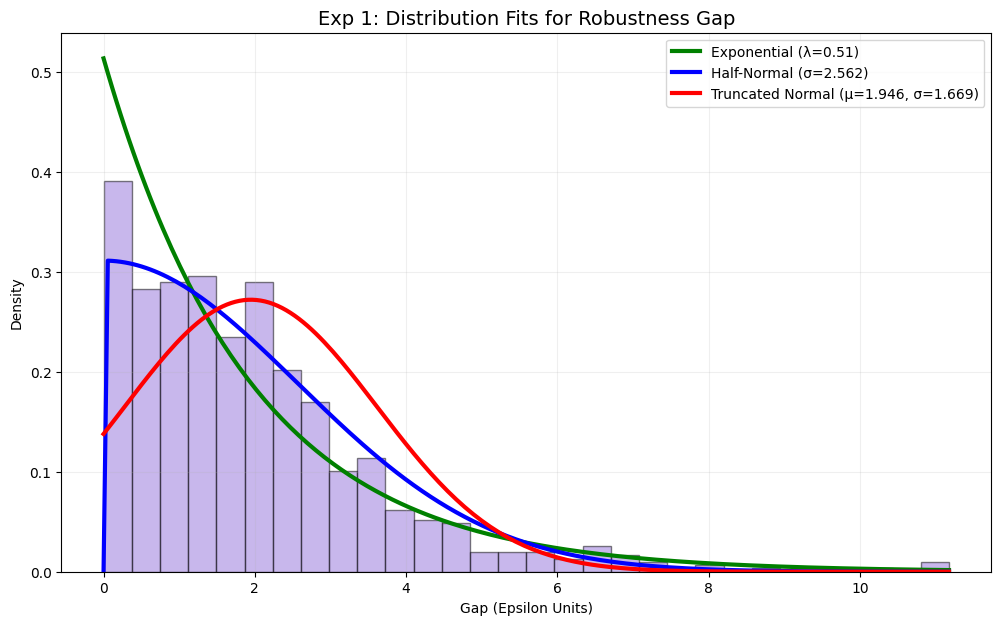

--- Fit Summary (Experiment 1) ---
Mean Gap: 1.946462
Samples at zero (approx): 0 out of 824

--- Relationship Statistics ---
Covariance (Fast-Lin vs Exact): 5.04859887
Correlation (Pearson R):       0.954088

Full Covariance Matrix:
[[ 2.76890831  5.04859887]
 [ 5.04859887 10.11245126]]


In [13]:
# 1. Align the data for Experiment 1
df_merged = pd.merge(
    df_fast[['name', 'imageIndex', 'epsilon']], 
    df_exact[['name', 'imageIndex', 'epsilon']], 
    on=['name', 'imageIndex'], 
    suffixes=('_fast', '_exact')
)

# Calculate the gap
df_merged['gap'] = (df_merged['epsilon_fast'] - df_merged['epsilon_exact']).abs()
data = df_merged['gap'].dropna()

# 2. Setup the Plot
plt.figure(figsize=(12, 7))
counts, bins, _ = plt.hist(data, bins=30, color='mediumpurple', edgecolor='black', alpha=0.5, density=True)
x = np.linspace(0, data.max(), 200)

# --- Fit 1: Exponential ---
loc_ex, scale_ex = stats.expon.fit(data, floc=0) 
plt.plot(x, stats.expon.pdf(x, loc_ex, scale_ex), color='green', lw=3, 
         label=f'Exponential (λ={1/scale_ex:.2f})')

# --- Fit 2: Half-Normal ---
loc_hn, scale_hn = stats.halfnorm.fit(data)
plt.plot(x, stats.halfnorm.pdf(x, loc_hn, scale_hn), color='blue', lw=3, 
         label=f'Half-Normal (σ={scale_hn:.3f})')

# --- Fit 3: Truncated Normal ---
mu_guess, std_guess = data.mean(), data.std()
a_bound = (0 - mu_guess) / std_guess
plt.plot(x, stats.truncnorm.pdf(x, a_bound, np.inf, loc=mu_guess, scale=std_guess), 
         color='red', lw=3, label=f'Truncated Normal (μ={mu_guess:.3f}, σ={std_guess:.3f})')

# 3. Finalize Plot
plt.title("Exp 1: Distribution Fits for Robustness Gap", fontsize=14)
plt.xlabel("Gap (Epsilon Units)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 4. Statistics & Covariance
# Calculate Covariance Matrix between the two epsilon columns
cov_matrix = np.cov(df_merged['epsilon_fast'], df_merged['epsilon_exact'])
covariance_val = cov_matrix[0, 1]
correlation_val = df_merged['epsilon_fast'].corr(df_merged['epsilon_exact'])

print(f"--- Fit Summary (Experiment 1) ---")
print(f"Mean Gap: {data.mean():.6f}")
print(f"Samples at zero (approx): {len(data[data < 1e-5])} out of {len(data)}")

print(f"\n--- Relationship Statistics ---")
print(f"Covariance (Fast-Lin vs Exact): {covariance_val:.8f}")
print(f"Correlation (Pearson R):       {correlation_val:.6f}")
print("\nFull Covariance Matrix:")
print(cov_matrix)

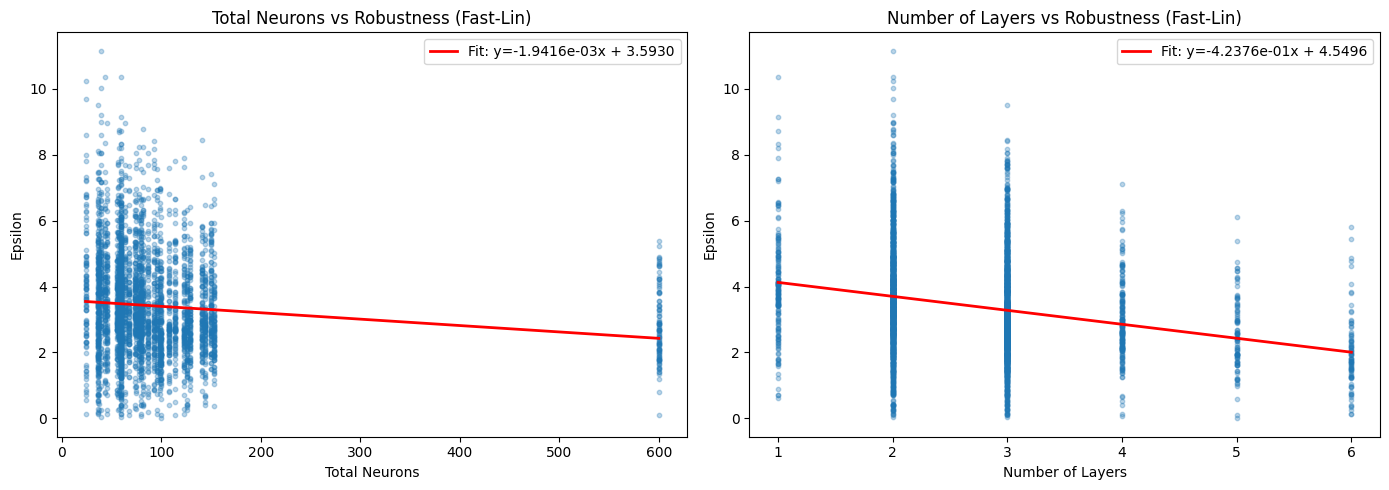

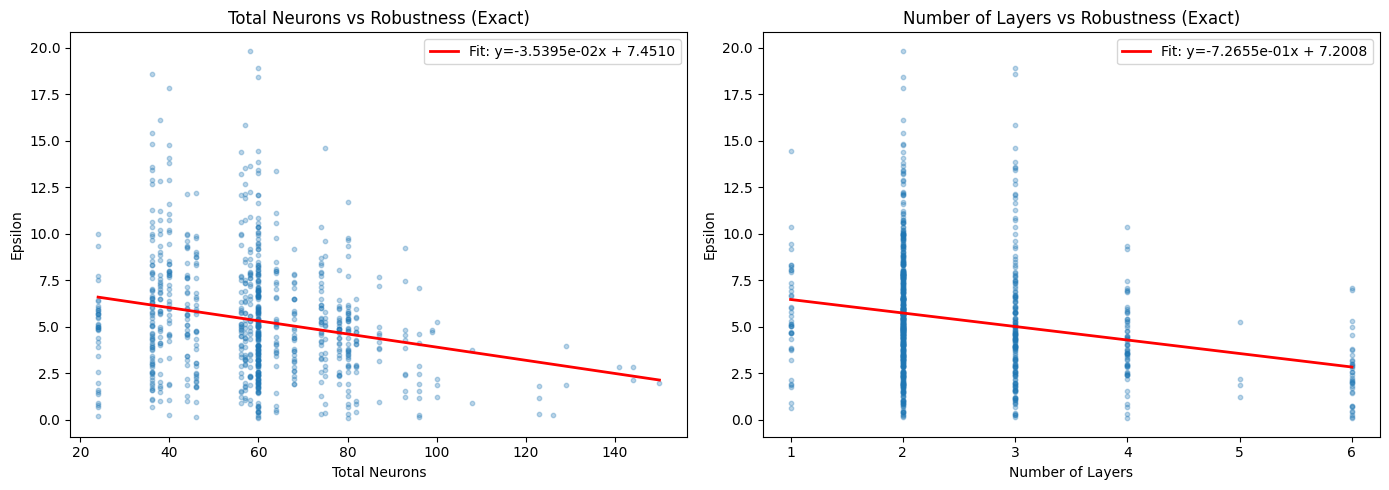

In [10]:
def extract_arch_features(name):
    # Extracts info from names like 'Dense1x60' or 'Dense3x32'
    match = re.search(r'Dense(\d+)x(\d+)', name)
    if match:
        layers = int(match.group(1))
        neurons_per_layer = int(match.group(2))
        return pd.Series({'layers': layers, 'neurons': layers * neurons_per_layer})
    return pd.Series({'layers': None, 'neurons': None})

# Helper to plot scatter with least-squares line
def plot_robustness_correlation(df, title_suffix):
    # Join architectural data
    arch_df = df['name'].apply(extract_arch_features)
    data = pd.concat([df[['epsilon']], arch_df], axis=1).dropna()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    features = [('neurons', 'Total Neurons'), ('layers', 'Number of Layers')]
    for ax, (feat_col, feat_label) in zip([ax1, ax2], features):
        x = data[feat_col].values
        y = data['epsilon'].values
        ax.scatter(x, y, alpha=0.3, s=10)
        
        # Calculate least-squares line
        m, c = np.polyfit(x, y, 1)
        x_range = np.array([x.min(), x.max()])
        ax.plot(x_range, m*x_range + c, color='red', lw=2, label=f'Fit: y={m:.4e}x + {c:.4f}')
        
        ax.set_title(f"{feat_label} vs Robustness ({title_suffix})")
        ax.set_xlabel(feat_label)
        ax.set_ylabel("Epsilon")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_robustness_correlation(df_fast, "Fast-Lin")
plot_robustness_correlation(df_exact, "Exact")

In [8]:
for df, title in [(df_fast, "Fast-Lin"), (df_exact, "Exact")]:
    # Prepare data
    arch_df = df['name'].apply(extract_arch_features)
    data = pd.concat([df[['epsilon']], arch_df], axis=1).dropna()
    
    # Normalize (Standardize)
    # This makes the covariance equivalent to correlation
    norm_data = (data - data.mean()) / data.std()
    
    # Calculate Sample Covariance
    cov_matrix = norm_data.cov()
    
    print(f"\n=== {title} Statistical Analysis ===")
    print(f"Sample Covariance (Normalized):")
    print(f"  Neurons vs Robustness: {cov_matrix.loc['neurons', 'epsilon']:.4f}")
    print(f"  Layers vs Robustness:  {cov_matrix.loc['layers', 'epsilon']:.4f}")
    
    # Fit Linear Predictor: Robustness = a*(neurons) + b*(layers) + c
    X = data[['neurons', 'layers']]
    y = data['epsilon']
    
    model = LinearRegression().fit(X, y)
    a, b = model.coef_
    c = model.intercept_
    
    print(f"Best Linear Predictor:")
    print(f"  Robustness = ({a:.6f} * Neurons) + ({b:.6f} * Layers) + {c:.6f}")


=== Fast-Lin Statistical Analysis ===
Sample Covariance (Normalized):
  Neurons vs Robustness: -0.1440
  Layers vs Robustness:  -0.2505
Best Linear Predictor:
  Robustness = (-0.003132 * Neurons) + (-0.391823 * Layers) + 4.735999

=== Exact Statistical Analysis ===
Sample Covariance (Normalized):
  Neurons vs Robustness: -0.2082
  Layers vs Robustness:  -0.2341
Best Linear Predictor:
  Robustness = (-0.028600 * Neurons) + (-0.622460 * Layers) + 8.610982
